In [2]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 56.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=2141c2f4d2a575d27362ad5524b617a47c2408e0c5027ef621bf30f7482be70a
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd "/content/drive/MyDrive/ソーセージ＿画像フォルダー"

/content/drive/MyDrive/ソーセージ＿画像フォルダー


In [5]:
from PIL import Image,ImageOps
import os, glob
import numpy as np
from PIL import ImageFile
# IOError: image file is truncated (0 bytes not processed)を回避するために必要
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [6]:
# dogsとcatsにある画像の縦、横の長さの平均を計算
import cv2
regions = ["0_北海道新", "1_東北新", "2_関東新", "3_中部新", "4_北陸新","5_近畿新", "6_中国新", "7_四国新", "8_九州新", "9_沖縄新"]

wh = [] # 画像の横の長さを格納するリスト
ht = [] # 画像の縦の長さを格納するリスト

for region in regions:
  photos = glob.glob(region + "/*.png")
  for file in photos:
      photo = cv2.imread(file)
      if photo is not None: # 画像が正常に読み込まれたかを確認
          h, w = photo.shape[:2] # 画像の縦の長さ（h）、横の長さ（w）を取得
          wh.append(w) # w の値を wh に格納
          ht.append(h) # h の値を ht に格納
      else:
          print(f"Warning: Could not read image file: {file}") # 読み込めなかった画像ファイルを出力
ht_resize = int(np.mean(ht)) # ht の値の平均の小数点以下を切り捨てた値を計算
wh_resize = int(np.mean(wh)) # wh の値の平均の小数点以下を切り捨てた値を計算
classes = ["0_北海道新", "1_東北新", "2_関東新", "3_中部新", "4_北陸新","5_近畿新", "6_中国新", "7_四国新", "8_九州新", "9_沖縄新"]
num_classes = len(classes)

X_train = [] # 訓練データを入れる配列
X_test  = [] # テストデータを入れる配列
y_train = [] # 訓練データのラベルを入れる配列
y_test  = [] # テストデータのラベルを入れる配列
#-追加
from sklearn.model_selection import train_test_split

X_all = [] # 全データを入れる配列
y_all = [] # 全ラベルを入れる配列

for index, classlabel in enumerate(classes):
    photos_dir = "./" + classlabel
    files = glob.glob(photos_dir + "/*.png") # png画像を取り込む場合、"/*.jpg"を"/*.png"に変更する
    num_testdata = int(len(files) * 0.2)
    for i, file in enumerate(files):
        image = Image.open(file)
        image = image.convert("RGB") # RGB（赤、緑、青）に変換（画像の配色データをRGBの順に統一）
        image = ImageOps.pad(image, (wh_resize, ht_resize), color=(0, 0, 0))
        data = np.asarray(image)
        #-追加
        X_all.append(data)
        y_all.append(index)
#-追加
X_all = np.array(X_all)
y_all = np.array(y_all)
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

#Numpy配列を保存
np.save("./regions_X_train.npy", X_train)
np.save("./regions_X_test.npy", X_test)
np.save("./regions_y_train.npy", y_train)
np.save("./regions_y_test.npy", y_test)

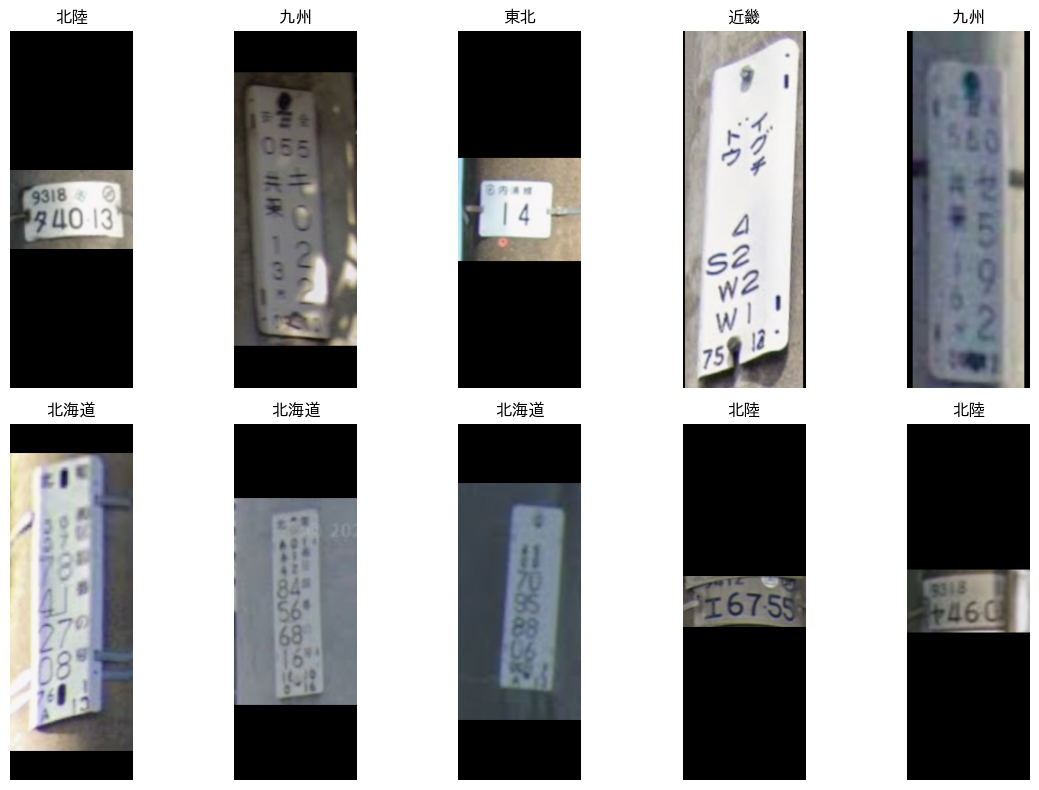

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# 保存したファイルを読み込む
X_train = np.load("./regions_X_train.npy")
y_train = np.load("./regions_y_train.npy")

# クラス名の定義（表示用）
classes = ["北海道", "東北", "関東", "中部", "北陸", "近畿", "中国", "四国", "九州", "沖縄"]

# 画像を表示する設定
plt.figure(figsize=(12, 8))

# 最初の10枚を表示してみる
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])  # 画像を表示
    plt.title(classes[y_train[i]]) # 対応するラベルを表示
    plt.axis('off') # 軸を非表示にする

plt.tight_layout()
plt.show()

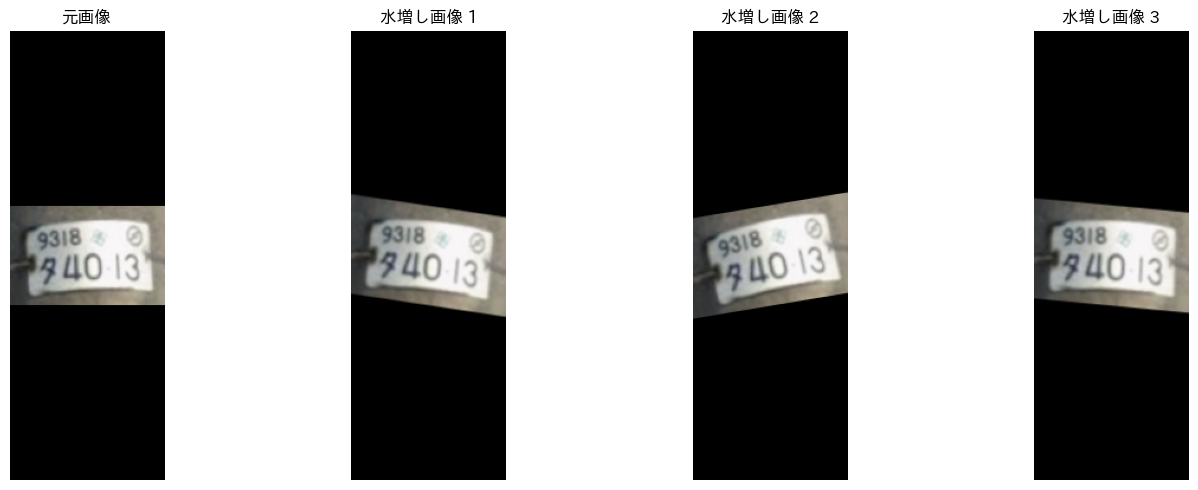

In [30]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
# 保存した画像データをロード
X_train2 = np.load("./regions_X_train.npy", allow_pickle=True)
X_test2 = np.load("./regions_X_test.npy", allow_pickle=True)
y_train2 = np.load("./regions_y_train.npy", allow_pickle=True)
y_test2 = np.load("./regions_y_test.npy", allow_pickle=True)

X_train2 = X_train2.astype(np.float32) / 255 # 各画素値を0-1の範囲で正規化
X_test2 = X_test2.astype(np.float32) / 255 # 各画素値を0-1の範囲で正規化
y_train2 = y_train2.astype(np.float32)
y_test2 = y_test2.astype(np.float32)
train_dataset = tf.data.Dataset.from_tensor_slices((X_train2, y_train2)) # 訓練データのtf.data.Dataset
test_dataset = tf.data.Dataset.from_tensor_slices((X_test2, y_test2)) # テストデータのtf.data.Dataset

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, RandomFlip, RandomRotation, RandomZoom,BatchNormalization,RandomContrast,RandomBrightness,GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import matplotlib.pyplot as plt
batch_size = 16 # バッチサイズ　解像度あげたので下げた
shuffle_buffer_size = len(train_dataset) # データをシャッフルするときのバッファサイズ
epochs = 50 # エポック数
IMG_HEIGHT = ht_resize # 画像の高さ（縦）のサイズ
IMG_WIDTH = wh_resize # 画像の幅（横）のサイズ
train_dataset2 = train_dataset.shuffle(shuffle_buffer_size).batch(batch_size)
test_dataset2 = test_dataset.batch(batch_size)
#-追加
data_augmentation = Sequential([
  tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
  RandomRotation(0.03), # 少し回転
  RandomZoom(0.03),     # 少しズーム
])
import matplotlib.pyplot as plt
import tensorflow as tf

# 確認のために元となる画像を1枚選ぶ（ここでは正規化済みのX_train2の最初の画像）
sample_image = X_train2[0]

# グラフのサイズ設定
plt.figure(figsize=(15, 5))

# 1. 左端に元の画像を表示
plt.subplot(1, 4, 1)
plt.imshow(sample_image)
plt.title("元画像")
plt.axis('off')

# モデルに入れるためにバッチ次元を追加（1枚の画像 → 1枚ずつの束にする）
image_batch = tf.expand_dims(sample_image, 0)

# 2. 水増しを3回適用して横に並べて表示
for i in range(3):
    # training=True を指定することで、ランダムな水増し機能を強制的にオンにする
    augmented_image = data_augmentation(image_batch, training=True)

    # バッチ次元を外して元の画像データに戻す
    img_to_show = augmented_image[0]

    plt.subplot(1, 4, i + 2)
    plt.imshow(img_to_show)
    plt.title(f"水増し画像 {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()
model = Sequential([
    data_augmentation,
    # 1段目の目（特徴抽出）
    Conv2D(8, (3, 3), activation='relu'),
    BatchNormalization(), # 【追加技術2】バッチ正規化で学習を安定・高速化
    MaxPooling2D((2, 2)),

    # 2段目の目（より複雑な特徴を探す）
    Conv2D(16, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # 3段目の目（さらに深く！）
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # 判定層へ
    #Flatten(),
    GlobalAveragePooling2D(),
    Dense(32, activation='relu'),
    BatchNormalization(), # ここにも入れると効果的
    Dropout(0.5),         # 演習⑥の過学習防止も忘れずに
    Dense(10, activation='softmax') # 10クラス分類の場合
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # ラベルが整数値なので、"sparse_"を付ける
              metrics=['accuracy'])

In [31]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau( #lossが改善しなかったら学習率を半分に下げる
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6
    ),
    tf.keras.callbacks.EarlyStopping( #伸び悩んだら終わる
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        mode='max'                # ← accuracyは大きいほど良いのでmax
    ),
]

history = model.fit(
    train_dataset2,
    epochs=epochs,
    validation_data=test_dataset2,
    callbacks=callbacks,
)
#history=model.fit(train_dataset2, epochs=epochs, validation_data=test_dataset2)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.1641 - loss: 3.1158 - val_accuracy: 0.1212 - val_loss: 2.3020 - learning_rate: 0.0010
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2344 - loss: 2.5191 - val_accuracy: 0.1515 - val_loss: 2.2877 - learning_rate: 0.0010
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2656 - loss: 2.2414 - val_accuracy: 0.1818 - val_loss: 2.2771 - learning_rate: 0.0010
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3203 - loss: 2.1006 - val_accuracy: 0.1515 - val_loss: 2.2693 - learning_rate: 0.0010
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3125 - loss: 2.0414 - val_accuracy: 0.1515 - val_loss: 2.2675 - learning_rate: 0.0010
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3672 - loss: 1.9212 - val_accuracy: 0.1515 - val_loss: 2.2633 - learning_rate: 0.0010
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4297 - loss: 1.7514 - val_accuracy: 0.1515 

5. 学習結果をグラフで表示します...


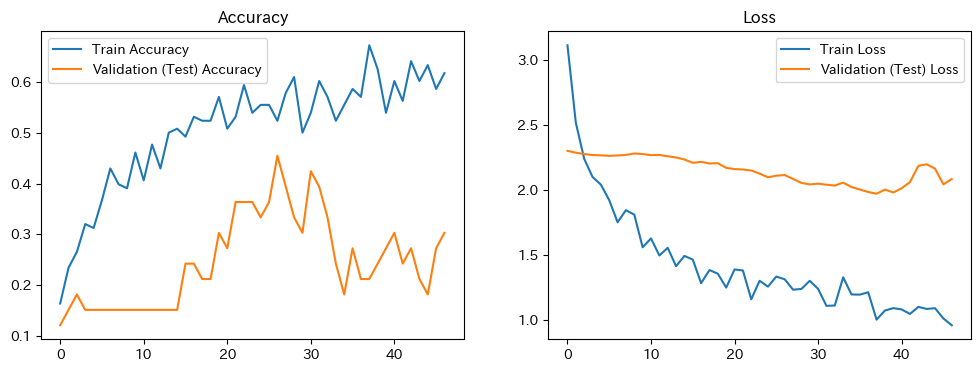

6. テストデータでの最終評価...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4545 - loss: 2.1152 


[2.1152377128601074, 0.4545454680919647]

In [32]:
print("5. 学習結果をグラフで表示します...")
# 学習の推移をグラフ化
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation (Test) Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation (Test) Loss')
plt.legend()
plt.title('Loss')
plt.show()

print("6. テストデータでの最終評価...")
model.evaluate(test_dataset2)